<a href="https://colab.research.google.com/github/NataliiaFakas/8-puzzle-toolkit/blob/main/4_Train_Dev_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

ruta_macro = "/content/drive/MyDrive/TFG_BMW/datasets/bmw_dataset_variables_macro.csv"
ruta_bmw = "/content/drive/MyDrive/TFG_BMW/datasets/ventas_bmw.csv"

df_macro = pd.read_csv(ruta_macro)
df_bmw = pd.read_csv(ruta_bmw)

display(df_macro.head())
display(df_bmw.head())

Mounted at /content/drive


,Year,Unemployment_Rate,GDP_Growth,Deposit_Facility,HICP,Industrial_Production,Retail_Sales_Growth,Consumer_Confidence,Compensation_Per_Employee,Brent_Oil_Price,EUR_USD,Euribor_12M,Population_Total
0,2005,8.9,1.7,1.25,2.18,153.2,0.03,-4.2,31.22,54.57,1.2441,2.19,434585887
1,2006,8.2,3.2,2.50,2.19,147.7,0.04,-3.5,31.95,65.16,1.2556,3.08,436041018
2,2007,7.2,2.9,3.00,2.13,145.5,0.03,-2.1,32.75,72.44,1.3705,4.24,437514477
3,2008,7.1,0.4,2.00,3.30,148.0,0.01,-10.8,33.86,96.94,1.4708,4.63,439074280
4,2009,9.0,-4.4,0.25,0.29,144.5,-0.03,-21.7,34.41,61.74,1.3948,1.31,440467898


,Año,Ventas_BMW_Unidades
0,2005,1126768
1,2006,1185088
2,2007,1276793
3,2008,1202239
4,2009,1068770


In [2]:
variables_modelo = [
    "Year",
    "Compensation_Per_Employee",
    "Industrial_Production",
    "Population_Total",
    "EUR_USD"
]

df_macro_reducido = df_macro[variables_modelo]

df_macro_reducido.head()

,Year,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD
0,2005,31.22,153.2,434585887,1.2441
1,2006,31.95,147.7,436041018,1.2556
2,2007,32.75,145.5,437514477,1.3705
3,2008,33.86,148.0,439074280,1.4708
4,2009,34.41,144.5,440467898,1.3948


In [3]:
def añadir_variables_macro(df_bmw, df_macro):

    df_final = df_bmw.merge(
        df_macro[variables_modelo],
        on="Year",
        how="left"
    )

    return df_final

In [5]:
df_bmw_filtrado = df_bmw.rename(columns={"Año": "Year"})

data = añadir_variables_macro(df_bmw_filtrado, df_macro_reducido)

display(data.head())
print("Shape del dataset definitivo:", data.shape)

,Year,Ventas_BMW_Unidades,Compensation_Per_Employee,Industrial_Production,Population_Total,EUR_USD
0,2005,1126768,31.22,153.2,434585887,1.2441
1,2006,1185088,31.95,147.7,436041018,1.2556
2,2007,1276793,32.75,145.5,437514477,1.3705
3,2008,1202239,33.86,148.0,439074280,1.4708
4,2009,1068770,34.41,144.5,440467898,1.3948


Shape del dataset definitivo: (21, 6)


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42  # semilla fija para reproducibilidad

X = data.drop(columns=["Year", "Ventas_BMW_Unidades"])
y = data["Ventas_BMW_Unidades"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (21, 4)
y shape: (21,)


In [7]:
# --- Partición train (70%) / dev (15%) / test (15%) ---
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, shuffle=True
)
X_dev, X_test, y_dev, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, shuffle=True
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Dev:   {X_dev.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 14 muestras
Dev:   3 muestras
Test:  4 muestras


In [8]:
# --- Barrido de hiperparámetros: n_estimators y min_impurity_decrease ---
n_estimators_grid = [10, 25, 50, 100, 200, 300]
min_impurity_decrease_grid = [0.0, 1e6, 5e6, 1e7, 5e7, 1e8]
# min_impurity_decrease está en la misma escala que el MSE (unidades de coches al cuadrado);
# se ajustará el rango si el mínimo cae en el borde del grid.

resultados = []
for n_est in n_estimators_grid:
    for mid in min_impurity_decrease_grid:
        modelo = RandomForestRegressor(
            n_estimators=n_est,
            min_impurity_decrease=mid,
            random_state=RANDOM_STATE
        )
        modelo.fit(X_train, y_train)
        pred_dev = modelo.predict(X_dev)
        mse_dev = mean_squared_error(y_dev, pred_dev)
        resultados.append({
            "n_estimators": n_est,
            "min_impurity_decrease": mid,
            "MSE_dev": mse_dev
        })

df_resultados = pd.DataFrame(resultados).sort_values("MSE_dev")
display(df_resultados.head(10))

,n_estimators,min_impurity_decrease,MSE_dev
0,10,0.0,5.724120e+09
1,10,1000000.0,5.724120e+09
2,10,5000000.0,5.724120e+09
3,10,10000000.0,5.724120e+09
4,10,50000000.0,5.753907e+09
5,10,100000000.0,5.767147e+09
35,300,100000000.0,7.715352e+09
30,300,0.0,7.826314e+09
32,300,5000000.0,7.826344e+09
31,300,1000000.0,7.826344e+09


In [9]:
# --- Mejor combinación según MSE en dev ---
mejor = df_resultados.iloc[0]
print(f"Mejor combinación -> n_estimators={int(mejor['n_estimators'])}, "
      f"min_impurity_decrease={mejor['min_impurity_decrease']}, "
      f"MSE_dev={mejor['MSE_dev']:.2f}")

Mejor combinación -> n_estimators=10, min_impurity_decrease=0.0, MSE_dev=5724119738.17


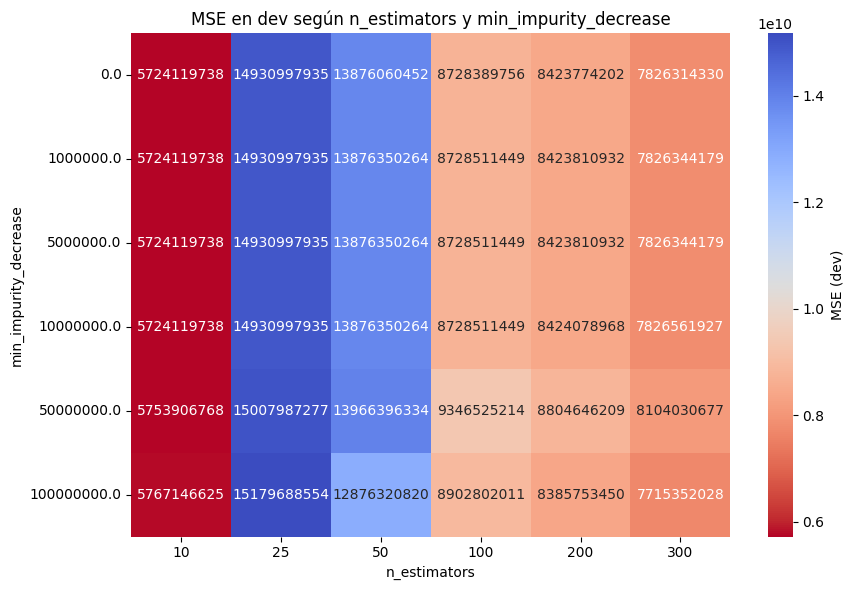

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Heatmap de MSE_dev por combinación de hiperparámetros ---
pivot = df_resultados.pivot(
    index="min_impurity_decrease",
    columns="n_estimators",
    values="MSE_dev"
)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm_r", cbar_kws={"label": "MSE (dev)"})
plt.title("MSE en dev según n_estimators y min_impurity_decrease")
plt.xlabel("n_estimators")
plt.ylabel("min_impurity_decrease")
plt.tight_layout()
plt.show()

In [11]:
# --- Reentrenar con la mejor combinación de hiperparámetros y evaluar en test ---
modelo_final = RandomForestRegressor(
    n_estimators=int(mejor["n_estimators"]),
    min_impurity_decrease=mejor["min_impurity_decrease"],
    random_state=RANDOM_STATE
)
modelo_final.fit(X_train, y_train)

pred_test = modelo_final.predict(X_test)
mse_test = mean_squared_error(y_test, pred_test)

print(f"MSE en test: {mse_test:.2f}")
print(f"RMSE en test: {np.sqrt(mse_test):.2f}")

MSE en test: 23814082256.50
RMSE en test: 154318.12


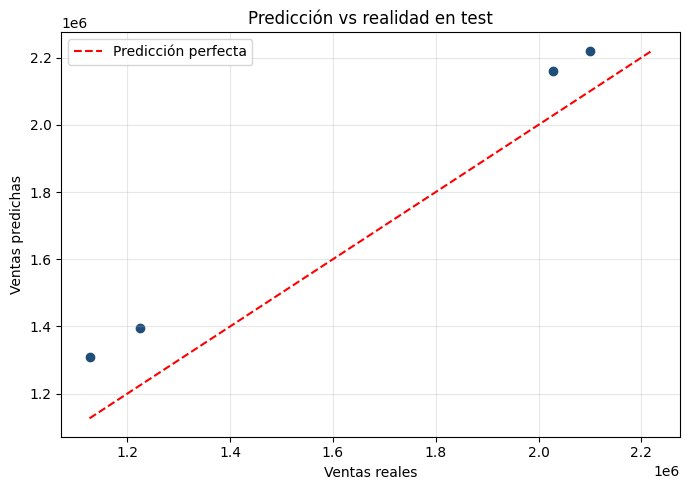

In [12]:
# --- Comparación visual: valores reales vs predichos en test ---
plt.figure(figsize=(7, 5))
plt.scatter(y_test, pred_test, color="#1F4E79")
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lims, lims, "r--", label="Predicción perfecta")
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Predicción vs realidad en test")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()